<a href="https://colab.research.google.com/github/Anish-S-tech/deep-learning-journey/blob/main/LeNet_architecture_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Importing necessary libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Step 2: Loading the dataset

mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test)= mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Step 3: Preprocessing the data

rows, cols= 28, 28

# Reshaping into 4D array

x_train= x_train.reshape(x_train.shape[0], rows, cols, 1)
x_test= x_test.reshape(x_test.shape[0], rows, cols, 1)

input_shape = (rows, cols, 1)

# datatype conversion and normalization

x_train = x_train.astype('float32')
x_test= x_test.astype('float32')

x_train = x_train/ 255.0
x_test= x_test/ 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)

In [7]:
# Step 4: Define LeNet-5 Model

def build_lenet(input_shape):

  # define the sequential model
  model = tf.keras.Sequential()

  # layer C1 (convolutional layer)
  model.add(tf.keras.layers.Conv2D(filters= 6, strides= (1,1), kernel_size= (5,5), activation= 'tanh', input_shape= input_shape))

  # layer S2 (subsampling layer)
  model.add(tf.keras.layers.AveragePooling2D(pool_size= (2,2), strides= (2,2)))

  # layer C3 (convolutional layer)
  model.add(tf.keras.layers.Conv2D(filters= 6, strides= (1,1), kernel_size= (5,5), activation= 'tanh'))

  # layer S4 (subsampling layer)
  model.add(tf.keras.layers.AveragePooling2D(pool_size= (2,2), strides= (2,2)))

  # layer C5 (convolutional layer)
  model.add(tf.keras.layers.Dense(units= 120, activation= 'tanh'))

  # Flatten to connect it to fully connected layer
  model.add(tf.keras.layers.Flatten())

  # layer FC6 (Fully Connected layer)
  model.add(tf.keras.layers.Dense(units=84, activation= 'tanh'))

  # Output layer
  model.add(tf.keras.layers.Dense(units=10, activation= 'softmax'))

  return model

In [10]:
# Step 5: Evaluating the model

lenet= build_lenet(input_shape)

# Compile the model
lenet.compile(optimizer= 'adam', loss= 'categorical_crossentropy', metrics= ['accuracy'])

# Training the model
epochs= 10
history = lenet.fit(x_train, y_train, epochs= epochs, batch_size= 128, verbose= 1)

# Checking accuracy and transform labels to one hot encoding

if len(y_test.shape)!=2 or y_test.shape[1]!= 10:
  y_test= tf.keras.utils.to_categorical(y_test, 10)

loss, acc= lenet.evaluate(x_test, y_test)
print("Accuracy:", acc)

x_train= x_train.reshape(x_train.shape[0], 28,28)
print("Training data",x_train.shape, y_train.shape)

x_test= x_test.reshape(x_test.shape[0], 28,28)
print("Testing data",x_test.shape, y_test.shape)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.9064 - loss: 0.3266
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - accuracy: 0.9614 - loss: 0.1291
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.9732 - loss: 0.0894
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.9791 - loss: 0.0696
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.9821 - loss: 0.0595
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 59ms/step - accuracy: 0.9841 - loss: 0.0513
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.9861 - loss: 0.0448
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.9873 - loss: 0.0409
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 59ms/step - accuracy: 0.9890 - loss: 0.0356
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 59ms/step - accuracy: 0.9900 - loss: 0.0326
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9854 - loss: 0.0463
Accuracy: 0.9854000210762024
Training data (

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
8


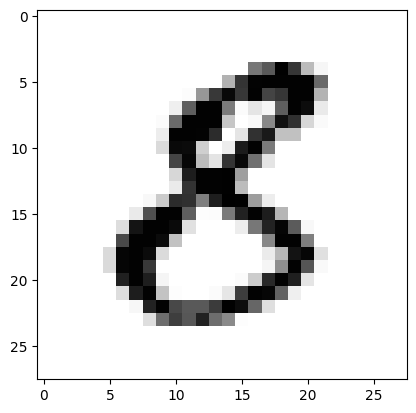

In [11]:

# Plotting the image
image_index= 1234
plt.imshow(x_test[image_index].reshape(28, 28), cmap= 'Greys')

# Make Prediction
pred= lenet.predict(x_test[image_index].reshape(1, rows, cols, 1))
print(pred.argmax())